In [2]:
# Importing the dependent modules
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
# Loading the  dataset into a pandas dataframe
dataset = pd.read_csv("Position_Salaries.csv")
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [7]:
print(X)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [8]:
print(y)

[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [10]:
# reshaping y to 2d array bacuse we need to scale dependent variable also
y = y.reshape(len(y), 1) # number or rows and number of columns
print(y)

[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


In [11]:
# Feature Scalling
# For svr regression features scalling is must otherwise there will be no good result
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X = sc_X.fit_transform(X)
# need to create seprate standard scalar otherwise it will fit the data based on previous one
sc_y = StandardScaler()
y = sc_y.fit_transform(y)

In [12]:
print(X)

[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]


In [13]:
print(y)

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


In [14]:
# Training the SVR model on the whole dataset
from sklearn.svm import SVR
regressor = SVR(kernel="rbf") # Kernel rbf => Radial basis Function
regressor.fit(X, y)

/home/kamrul/Desktop/python-ws/machine_learning/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

In [15]:
regressor.score(X, y)

0.7516001070620798

In [16]:
# Predicting the results
# Reverse scale the result cause we have applied sscalling in the output also
sc_y.inverse_transform(regressor.predict(sc_X.transform([[6.5]])).reshape(-1,1))

array([[170370.0204065]])

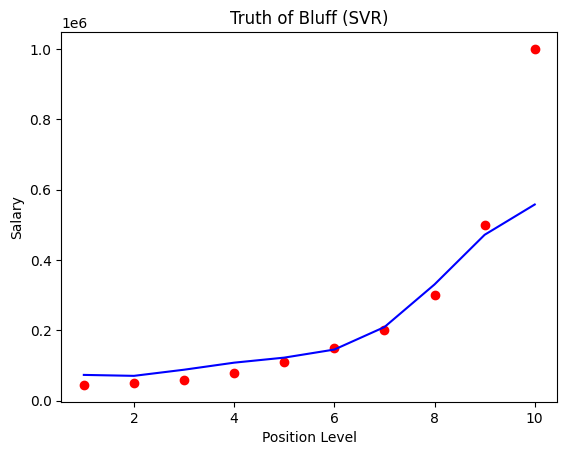

In [18]:
# Visualize the svr results
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color="red")
plt.plot(sc_X.inverse_transform(X), sc_y.inverse_transform(regressor.predict(X).reshape(-1,1)),color="blue")
plt.title("Truth of Bluff (SVR)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

/tmp/ipykernel_31008/3929835175.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(sc_X.inverse_transform(X)), max(sc_X.inverse_transform(X)), 0.1)


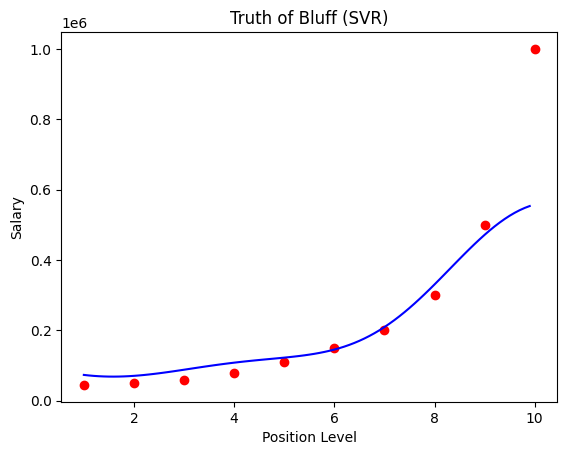

In [19]:
# Visualize the SVR results (for higher resolution and smoother curve)
X_grid = np.arange(min(sc_X.inverse_transform(X)), max(sc_X.inverse_transform(X)), 0.1)
X_grid = X_grid.reshape(len(X_grid), 1)
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color="red")
plt.plot(X_grid, sc_y.inverse_transform(regressor.predict(sc_X.transform(X_grid)).reshape(-1,1)),color="blue")
plt.title("Truth of Bluff (SVR)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()